# [LAB 09] 1. 선형회귀의 이해
## #연습문제 - 골턴의 유산

In [1]:
from hossam import load_data
from helpers import *
from pandas import DataFrame

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.21

⚠️  'hossam' 패키지의 최신 버전이 출시되었습니다! (설치된 버전: 0.5.21, 최신 버전: 0.5.23)
   최신 버전으로 업데이트하려면 다음 명령어를 실행하세요:
   pip install --upgrade hossam



In [2]:
origin = load_data('father-son')
origin.head()

📚 아버지와 아들의 키를 조사한 데이터 (출처: https://www.kaggle.com/datasets/aungdev/pearson-dataset-heights-of-fathers-and-their-sons)

field    description
-------  -------------------
fheight  아버지의 키(Inches)
sheight  아들의 키(Inches)



,fheight,sheight
0,65.049,59.778
1,63.251,63.214
2,64.955,63.342
3,65.752,62.792
4,61.137,64.281


##### 미션 1. 데이터와 친해지기
- 크기, 자료형, 기초통계량 확인
- 산점도를 그래 아버지 키와 아들 키 사이에 어떤 경향이 보이는지 눈으로 관찰
- 두 변수의 상관계수를 구하고 회귀분석을 적용해도 되는지 근거를 대라

In [3]:
origin.info()

<class 'pandas.DataFrame'>
RangeIndex: 1078 entries, 0 to 1077
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   fheight  1078 non-null   float64
 1   sheight  1078 non-null   float64
dtypes: float64(2)
memory usage: 17.0 KB


In [4]:
my_qtcheck.numerical_summary(origin).T

,fheight,sheight
count,1078.000,1078.000
mean,67.687,68.684
std,2.745,2.815
min,59.008,58.507
25%,65.788,66.931
50%,67.767,68.616
75%,69.603,70.466
max,75.434,78.365
rel_diff,0.001,0.001
rdiff_flag,similar,similar


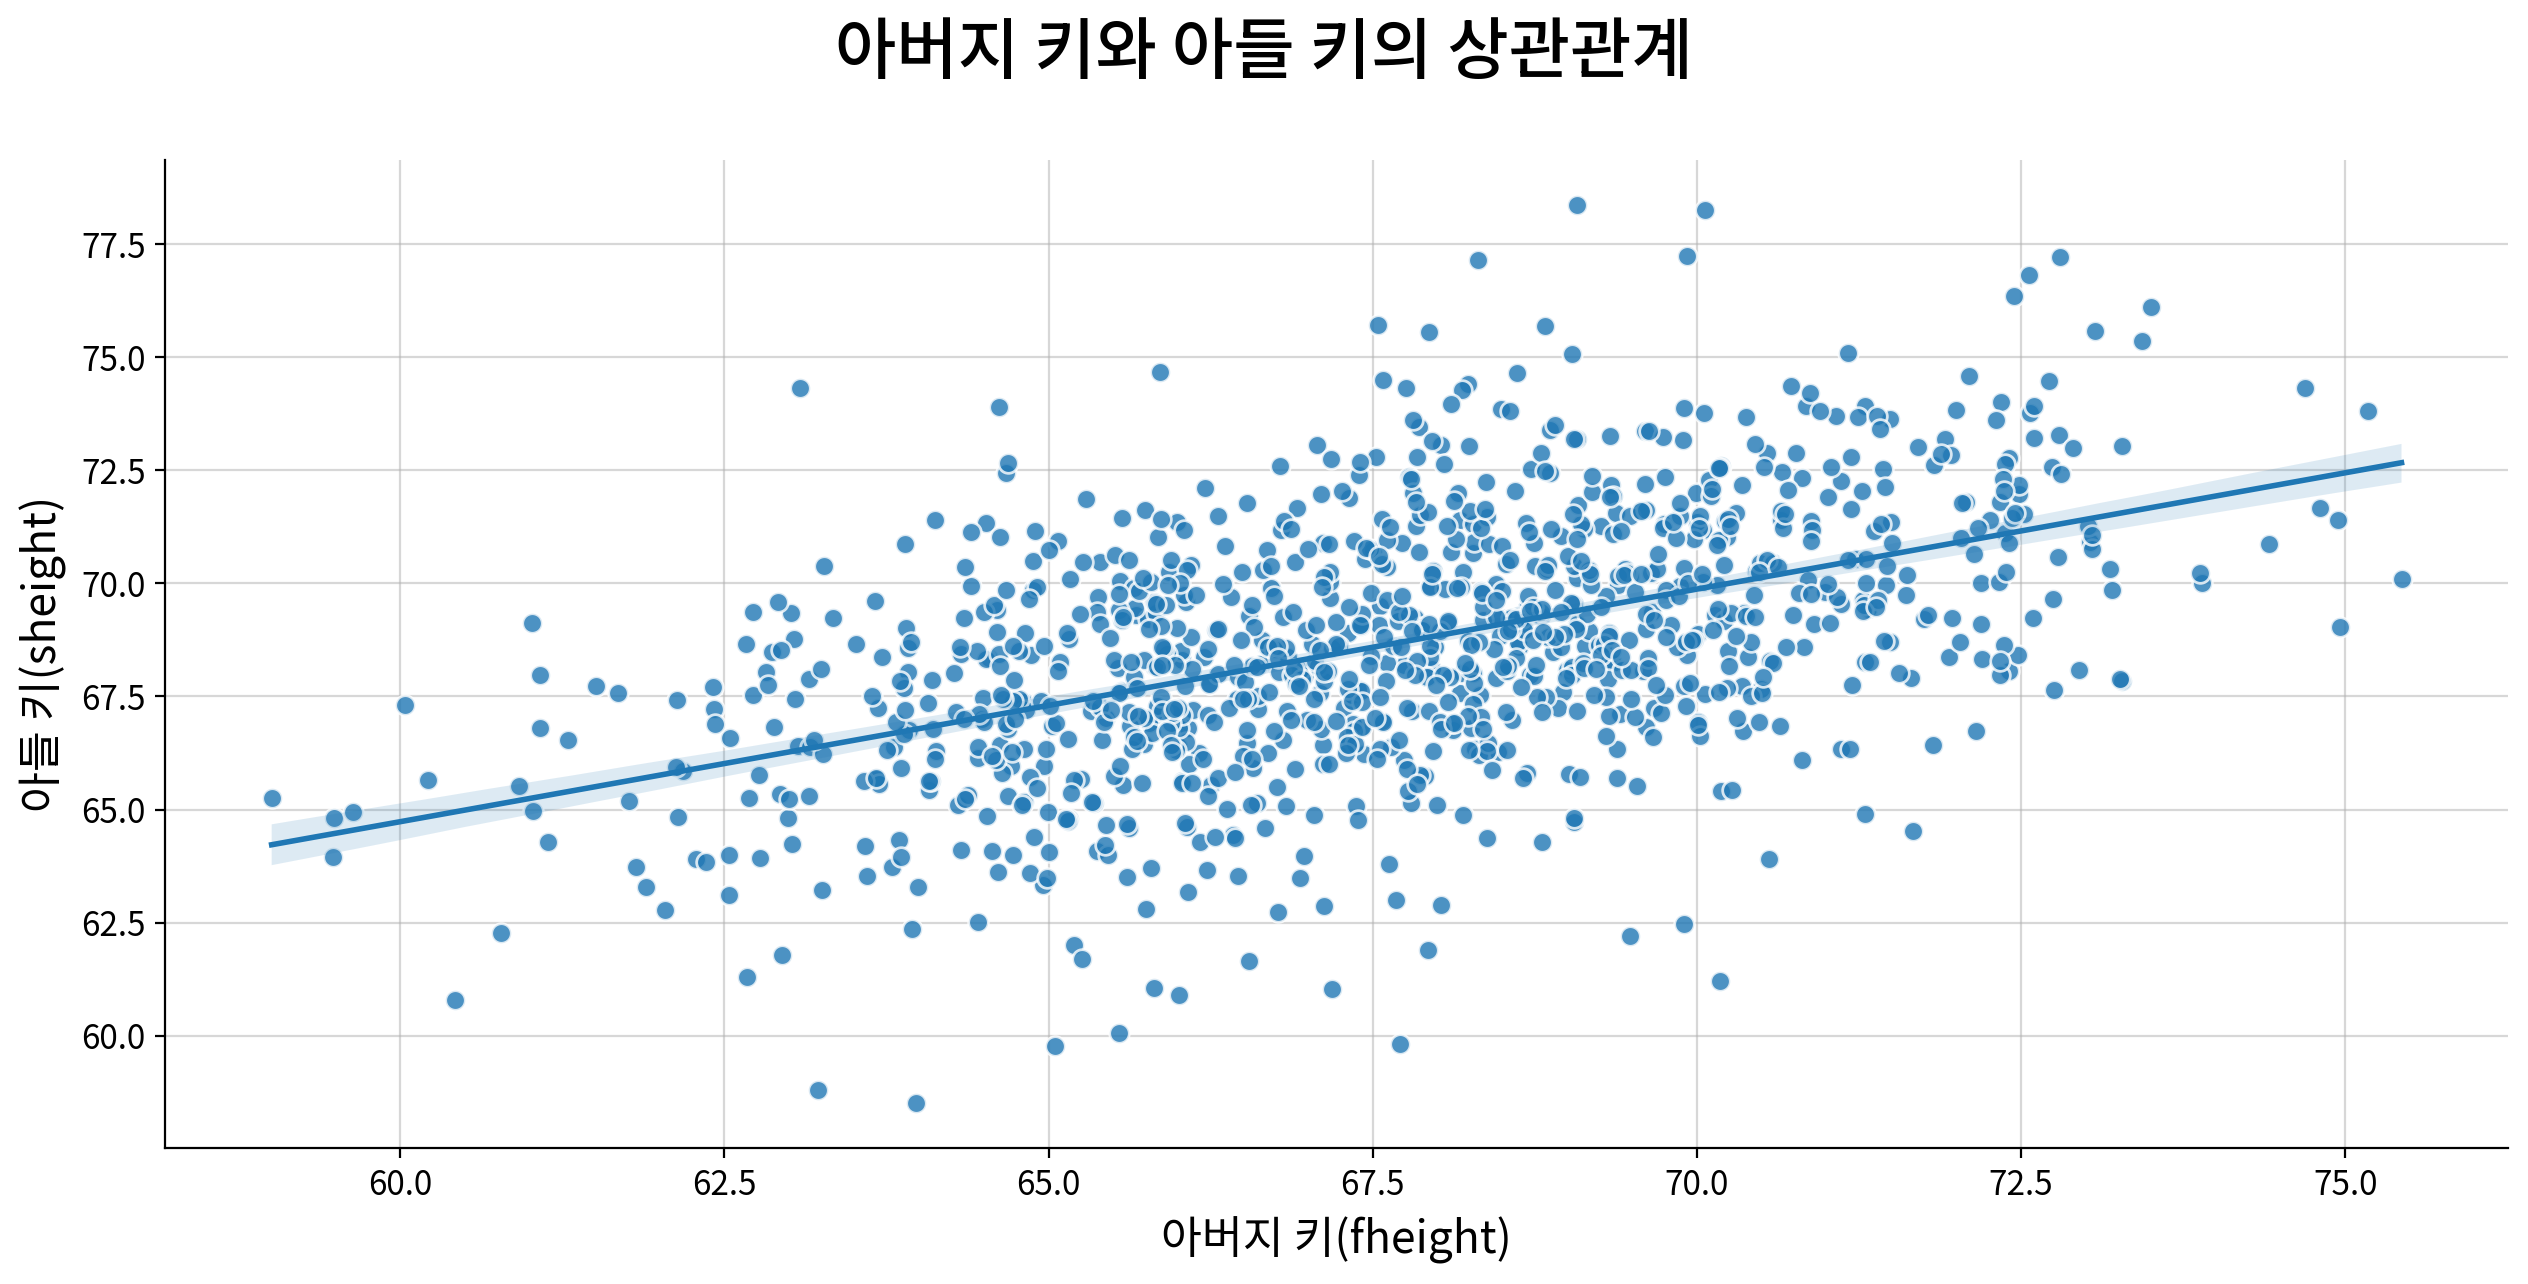

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
fheight,sheight,Spearman,0.506,0.000,Moderate,True,True,False,True,False,False


In [5]:
my_stats.correlation(origin,x='fheight', y='sheight', plot=True, title='아버지 키와 아들 키의 상관관계', xlabel='아버지 키(fheight)', ylabel='아들 키(sheight)')

p-value가 <0.001로 매우 유의하고 r이 0.506로 유의한 양의 중간 상관관계가 있고 선형성을 띄므로 회귀분석을 적용할 수 있음

##### 미션 2. 회귀식 유도하기
- 아들 키를 종속변수, 아버지 키를 독립변수로 하는 단순선형회귀모형
- 추정결과로부터 회귀식을 도출하여 제시

In [6]:
fit = my_ols.fit_model(origin, y='sheight', summary=True)

                            OLS Regression Results                            
Dep. Variable:                sheight   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     361.2
Date:                Mon, 06 Jul 2026   Prob (F-statistic):           1.12e-69
Time:                        12:27:44   Log-Likelihood:                -2488.7
No. Observations:                1078   AIC:                             4981.
Df Residuals:                    1076   BIC:                             4991.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.8866      1.832     18.493      0.0

- y= ax + b(단순선형회귀)
- a = 0.5141, b= 33.8866
- 예측할 수 있는 아들의 키 = 0.5141*아버지키 + 33.8866 

##### 미션 3. 아버지 키에 따른 아들의 키 예측
- 새로운 데이터셋을 만들어 앞어 유도한 회귀식으로 각자의 아들 키를 예측하라


In [45]:
from pandas import concat

df = origin.copy()
df['pred'] = float('nan')

new_fathers = DataFrame({'fheight': [62, 65, 68, 71, 74]})
new_fathers['sheight'] = float('nan')
new_fathers['pred'] = my_ols.predict(fit, new_fathers[['fheight']])['pred']

df = concat([df, new_fathers], ignore_index=True)
df.tail()

,fheight,sheight,pred
1078,62.000,NaN,65.760
1079,65.000,NaN,67.303
1080,68.000,NaN,68.845
1081,71.000,NaN,70.387
1082,74.000,NaN,71.929


##### 미션 4. 한장의 그래프로 보고하기

In [46]:
df_melt = df.melt(
    id_vars='fheight',
    value_vars=['sheight', 'pred'],
    var_name='variable',
    value_name='value'
)

df_melt.tail(10)

,fheight,variable,value
2156,66.997,pred,NaN
2157,71.332,pred,NaN
2158,71.783,pred,NaN
2159,70.738,pred,NaN
2160,70.306,pred,NaN
2161,62.000,pred,65.760
2162,65.000,pred,67.303
2163,68.000,pred,68.845
2164,71.000,pred,70.387
2165,74.000,pred,71.929


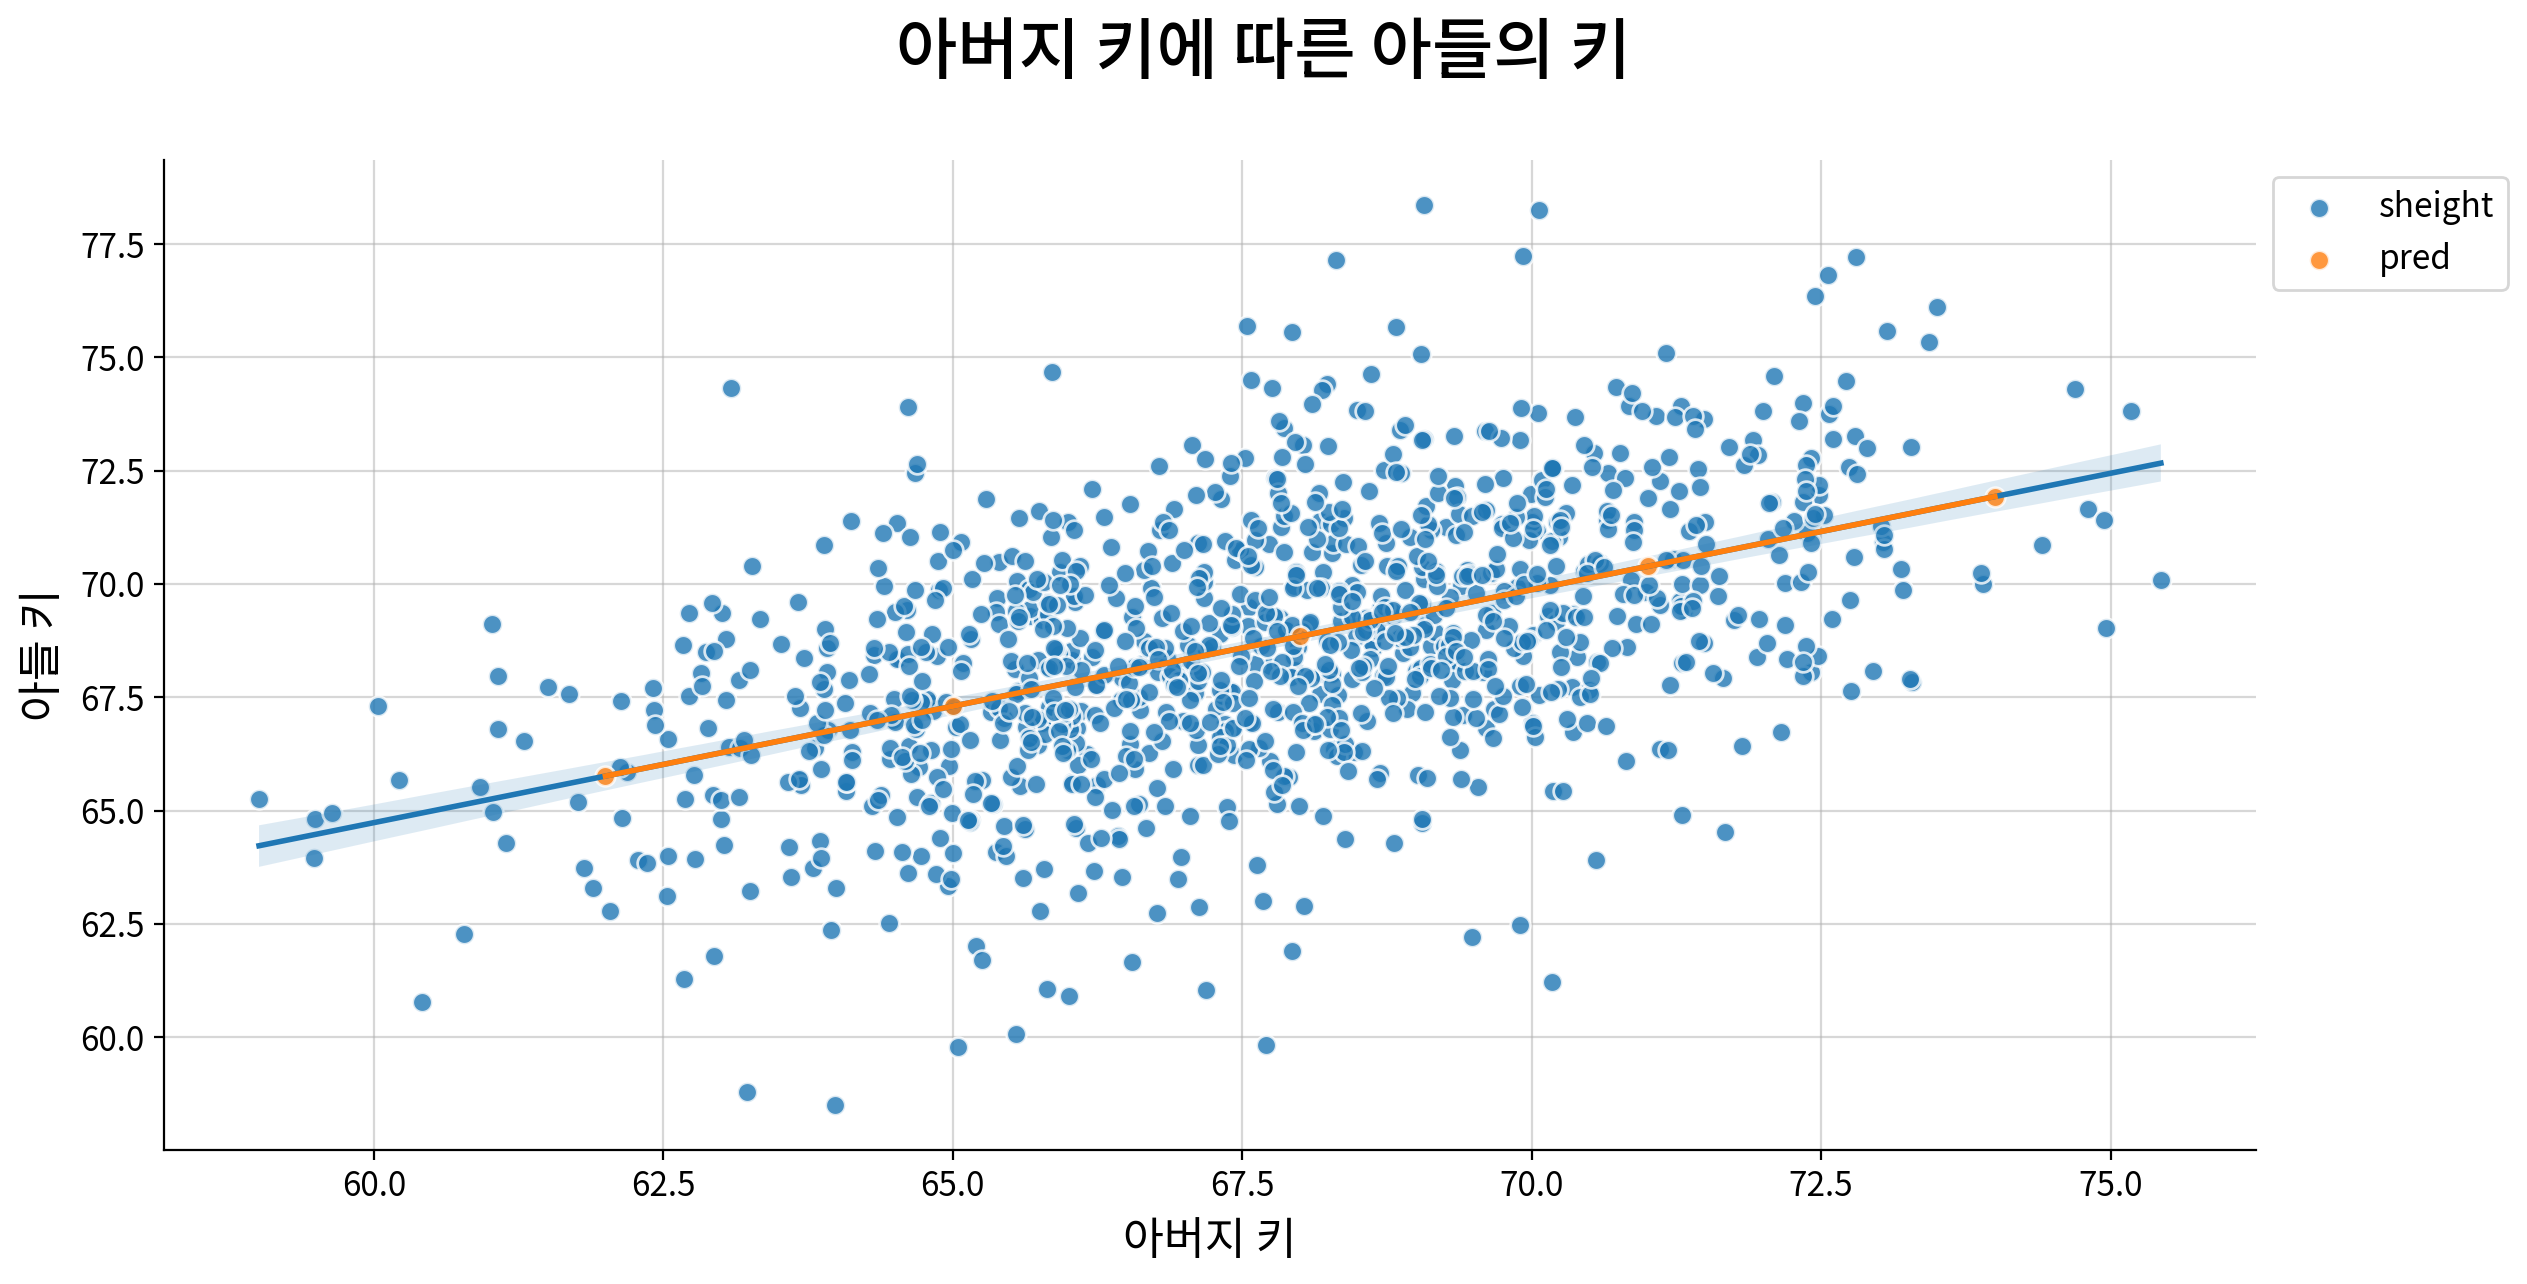

In [48]:
my_plot.lmplot(df_melt, x='fheight', y='value', hue='variable', title='아버지 키에 따른 아들의 키', xlabel='아버지 키', ylabel='아들 키')